<a href="https://colab.research.google.com/github/pitisolim/solim.github.io/blob/main/Final_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LEVEL 1 — TASK 1 : Data Collection and Web Scraping
Target   : https://books.toscrape.com  (sandbox scraping site)
Tools    : requests, BeautifulSoup, pandas

In [54]:


import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

BASE_URL = "https://books.toscrape.com/catalogue/"
START_URL = "https://books.toscrape.com/catalogue/page-1.html"

# ── Rating mapping ──────────────────────────────────────────────────────────
RATING_MAP = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

def get_soup(url: str) -> BeautifulSoup:
    """Fetch a page and return its BeautifulSoup object."""
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    return BeautifulSoup(response.text, "html.parser")


def parse_books(soup: BeautifulSoup) -> list[dict]:
    """Extract book data from a catalogue page."""
    books = []
    articles = soup.select("article.product_pod")
    for article in articles:
        title  = article.h3.a["title"]
        price  = article.select_one("p.price_color").text.strip()
        rating = RATING_MAP.get(article.p["class"][1], 0)
        avail  = article.select_one("p.availability").text.strip()
        link   = BASE_URL + article.h3.a["href"].replace("../", "")
        books.append({
            "title"        : title,
            "price_gbp"    : float(price.replace("£", "").replace("Â", "")),
            "rating"       : rating,
            "availability" : avail,
            "url"          : link,
        })
    return books


def get_next_page(soup: BeautifulSoup) -> str | None:
    """Return the URL of the next catalogue page, or None if last page."""
    next_btn = soup.select_one("li.next > a")
    if next_btn:
        return BASE_URL + next_btn["href"]
    return None


def scrape_all_books(max_pages: int = 5) -> pd.DataFrame:
    """
    Scrape multiple catalogue pages (pagination handling).
    max_pages: limit for demo — remove limit for full 50-page scrape.
    """
    all_books = []
    url = START_URL
    page = 1

    while url and page <= max_pages:
        print(f"  Scraping page {page}: {url}")
        soup = get_soup(url)
        all_books.extend(parse_books(soup))
        url = get_next_page(soup)
        page += 1
        time.sleep(0.5)          # polite delay between requests

    return pd.DataFrame(all_books)


# ── Main ─────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=== Web Scraping: books.toscrape.com ===\n")

    df = scrape_all_books(max_pages=5)

    print(f"\nScraped {len(df)} books from 5 pages.\n")
    print(df.head(10).to_string(index=False))

    # ── Save results ─────────────────────────────────────────────────────────
    df.to_csv("books_scraped.csv", index=False)
    df.to_json("books_scraped.json", orient="records", indent=2)
    print("\n✓ Saved: books_scraped.csv  |  books_scraped.json")

    # ── Quick summary ─────────────────────────────────────────────────────────
    print("\n── Summary Statistics ──────────────────────────────────")
    print(df[["price_gbp", "rating"]].describe().round(2))
    print("\nTop 5 cheapest books:")
    print(df.nsmallest(5, "price_gbp")[["title", "price_gbp", "rating"]].to_string(index=False))
    print("\nTop 5 highest-rated books:")
    print(df[df["rating"] == 5][["title", "price_gbp"]].head(5).to_string(index=False))


=== Web Scraping: books.toscrape.com ===

  Scraping page 1: https://books.toscrape.com/catalogue/page-1.html
  Scraping page 2: https://books.toscrape.com/catalogue/page-2.html
  Scraping page 3: https://books.toscrape.com/catalogue/page-3.html
  Scraping page 4: https://books.toscrape.com/catalogue/page-4.html
  Scraping page 5: https://books.toscrape.com/catalogue/page-5.html

Scraped 100 books from 5 pages.

                                                                                         title  price_gbp  rating availability                                                                                                                                               url
                                                                          A Light in the Attic      51.77       3     In stock                                                                         https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html
                                      

LEVEL 1 — TASK 2 : Data Cleaning and Preprocessing
Dataset  : Synthetic Titanic-style
Tools    : pandas, scikit-learn

In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler


In [56]:
np.random.seed(42)

In [57]:
print("=== Data Cleaning & Preprocessing — Titanic-style Dataset ===\n")

n = 891
df = pd.DataFrame({
    "survived"   : np.random.randint(0, 2, n),
    "pclass"     : np.random.choice([1, 2, 3], n, p=[0.24, 0.21, 0.55]),
    "sex"        : np.random.choice(["male", "female"], n, p=[0.65, 0.35]),
    "age"        : np.where(np.random.rand(n) < 0.20, np.nan,
                            np.random.normal(29, 13, n).clip(1, 80)),
    "sibsp"      : np.random.choice([0,1,2,3,4,5], n, p=[0.68,0.23,0.05,0.02,0.01,0.01]),
    "parch"      : np.random.choice([0,1,2,3,4,5], n, p=[0.76,0.13,0.08,0.01,0.01,0.01]),
    "fare"       : np.where(np.random.rand(n) < 0.01, np.nan,
                            np.random.exponential(32, n).clip(0, 512)),
    "embarked"   : np.random.choice(["S","C","Q", None], n, p=[0.70,0.19,0.09,0.02]),
    "deck"       : np.random.choice([None,"A","B","C","D","E","F","G"], n, p=[0.77,0.03,0.03,0.07,0.04,0.03,0.02,0.01]),
})

print(f"Shape: {df.shape}")
print("\nFirst rows:")
print(df.head())

=== Data Cleaning & Preprocessing — Titanic-style Dataset ===

Shape: (891, 9)

First rows:
   survived  pclass     sex        age  sibsp  parch       fare embarked  deck
0         0       3    male        NaN      0      0  45.015798        S     D
1         1       3    male   4.593242      0      0  35.703633        S  None
2         0       2    male  34.984288      0      1  24.242601        C  None
3         0       3    male  11.455865      0      0   3.331503        S  None
4         0       3  female        NaN      1      0  53.512609        S  None


In [58]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,NaN,0,0,45.015798,S,D
1,1,3,male,4.593242,0,0,35.703633,S,None
2,0,2,male,34.984288,0,1,24.242601,C,None
3,0,3,male,11.455865,0,0,3.331503,S,None
4,0,3,female,NaN,1,0,53.512609,S,None
...,...,...,...,...,...,...,...,...,...
886,0,3,male,29.609707,0,0,19.356663,S,None
887,1,2,male,38.060812,0,0,35.529660,S,None
888,1,3,male,NaN,0,0,12.263741,S,None
889,0,3,male,31.281435,1,2,15.360690,S,None


In [59]:
print("\n── Missing values ──────────────────────────────────────")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"Missing": missing, "Pct (%)": missing_pct})
      [missing > 0].sort_values("Pct (%)", ascending=False))



── Missing values ──────────────────────────────────────
          Missing  Pct (%)
deck          700    78.56
age           170    19.08
embarked       25     2.81
fare            8     0.90


In [60]:
print("\n── Handling Missing Data ───────────────────────────────")
df["age"].fillna(df["age"].median(), inplace=True)
print(f"  'age'  — imputed with median ({df['age'].median():.1f})")
df["fare"].fillna(df["fare"].mean(), inplace=True)
print(f"  'fare' — imputed with mean   ({df['fare'].mean():.2f})")
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)
print(f"  'embarked' — imputed with mode")



── Handling Missing Data ───────────────────────────────
  'age'  — imputed with median (28.9)
  'fare' — imputed with mean   (33.02)
  'embarked' — imputed with mode


In [61]:
threshold = 0.40
cols_drop = [c for c in df.columns if df[c].isnull().mean() > threshold]
df.drop(columns=cols_drop, inplace=True)
print(f"  Dropped cols > {threshold*100:.0f}% missing: {cols_drop}")
print(f"\n  Missing after cleaning: {df.isnull().sum().sum()}")


  Dropped cols > 40% missing: ['deck']

  Missing after cleaning: 0


In [62]:
print("\n── Outlier Removal (IQR) ───────────────────────────────")
num_cols = ["age", "fare", "sibsp", "parch"]

def remove_outliers_iqr(df, cols):
    initial = len(df)
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        before = len(df)
        df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]
        print(f"  {col:<8}: removed {before - len(df)} outliers")
    print(f"  Rows: {initial} → {len(df)}")
    return df

df = remove_outliers_iqr(df.copy(), num_cols)



── Outlier Removal (IQR) ───────────────────────────────
  age     : removed 42 outliers
  fare    : removed 38 outliers
  sibsp   : removed 23 outliers
  parch   : removed 173 outliers
  Rows: 891 → 615


In [63]:
print("\n── Encoding Categorical Variables ──────────────────────")
le = LabelEncoder()
df["sex_encoded"] = le.fit_transform(df["sex"])
print(f"  Label encoding 'sex': {dict(zip(le.classes_, le.transform(le.classes_)))}")

df = pd.get_dummies(df, columns=["embarked", "pclass"], drop_first=False, dtype=int)
df.drop(columns=["sex"], inplace=True)
print(f"  One-hot: embarked, pclass")
print(f"  Shape after encoding: {df.shape}")



── Encoding Categorical Variables ──────────────────────
  Label encoding 'sex': {'female': np.int64(0), 'male': np.int64(1)}
  One-hot: embarked, pclass
  Shape after encoding: (615, 12)


In [64]:
print("\n── Normalization & Standardization ─────────────────────")
num_features = ["age", "fare", "sibsp", "parch"]
scaler_std = StandardScaler()
df_std = df.copy()
df_std[num_features] = scaler_std.fit_transform(df[num_features])
scaler_mm = MinMaxScaler()
df_mm = df.copy()
df_mm[num_features] = scaler_mm.fit_transform(df[num_features])
print("  StandardScaler (mean≈0, std≈1):")
print(df_std[num_features].describe().round(3).loc[["mean","std"]])
print("\n  MinMaxScaler (range [0,1]):")
print(df_mm[num_features].describe().round(3).loc[["min","max"]])



── Normalization & Standardization ─────────────────────
  StandardScaler (mean≈0, std≈1):
        age   fare  sibsp  parch
mean -0.000  0.000  0.000    0.0
std   1.001  1.001  1.001    0.0

  MinMaxScaler (range [0,1]):
     age  fare  sibsp  parch
min  0.0   0.0    0.0    0.0
max  1.0   1.0    1.0    0.0


In [65]:
df.to_csv("titanic_cleaned.csv", index=False)
df_std.to_csv("titanic_standardized.csv", index=False)
print("\n✓ Saved: titanic_cleaned.csv  |  titanic_standardized.csv")
print(f"Final shape: {df.shape}")


✓ Saved: titanic_cleaned.csv  |  titanic_standardized.csv
Final shape: (615, 12)


In [66]:
df

,survived,age,sibsp,parch,fare,sex_encoded,embarked_C,embarked_Q,embarked_S,pclass_1,pclass_2,pclass_3
0,0,28.902300,0,0,45.015798,1,0,0,1,0,0,1
1,1,4.593242,0,0,35.703633,1,0,0,1,0,0,1
3,0,11.455865,0,0,3.331503,1,0,0,1,0,0,1
4,0,28.902300,1,0,53.512609,0,0,0,1,0,0,1
5,1,45.574859,0,0,64.322834,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
883,1,34.345368,0,0,6.608187,1,0,0,1,1,0,0
884,1,19.908863,0,0,10.042688,1,0,0,1,1,0,0
886,0,29.609707,0,0,19.356663,1,0,0,1,0,0,1
887,1,38.060812,0,0,35.529660,1,0,0,1,0,1,0


LEVEL 2 — TASK 1 : Predictive Modeling (Regression)
Dataset  : California Housing (sklearn)
Tools    : pandas, scikit-learn, matplotlib

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]


1. Load & prepare data

In [68]:
print("=== Regression — California Housing Prices ===\n")
# Use synthetic regression dataset
from sklearn.datasets import make_regression
X_np, y_np = make_regression(n_samples=5000, n_features=8, noise=50, random_state=42)
feat_names = [f"Feature_{i+1}" for i in range(8)]
df = pd.DataFrame(X_np, columns=feat_names)
df["target"] = y_np
print(f"Shape: {df.shape}")
print(df.describe().round(3))

X = df[feat_names]
y = df["target"]

=== Regression — California Housing Prices ===

Shape: (5000, 9)
       Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
count   5000.000   5000.000   5000.000   5000.000   5000.000   5000.000   
mean      -0.008     -0.015     -0.009     -0.013      0.013      0.027   
std        0.993      1.005      0.985      1.014      1.003      1.008   
min       -3.233     -3.837     -4.466     -3.922     -3.688     -3.376   
25%       -0.694     -0.707     -0.683     -0.701     -0.667     -0.653   
50%       -0.009      0.007     -0.005     -0.012      0.018      0.035   
75%        0.638      0.677      0.670      0.681      0.698      0.695   
max        3.926      3.728      3.335      3.378      4.479      3.611   

       Feature_7  Feature_8    target  
count   5000.000   5000.000  5000.000  
mean      -0.002     -0.010    -1.219  
std        1.003      0.989   164.950  
min       -3.655     -3.368  -572.658  
25%       -0.684     -0.679  -111.809  
50%       -0.016   

2. Train / Test split

In [69]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")


Train: 4000 samples | Test: 1000 samples


 3. Scale features

In [70]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

4. Train and evaluate multiple models

In [71]:
models = {
    "Linear Regression"        : LinearRegression(),
    "Ridge Regression"         : Ridge(alpha=1.0),
    "Lasso Regression"         : Lasso(alpha=0.01),
    "Decision Tree"            : DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest"            : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting"        : GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
}

results = []
predictions = {}

print("\n── Model Evaluation ────────────────────────────────────")
print(f"{'Model':<25} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print("─" * 55)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    predictions[name] = y_pred

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results.append({"Model": name, "R²": r2, "RMSE": rmse, "MAE": mae})
    print(f"  {name:<23} {r2:>8.4f} {rmse:>8.4f} {mae:>8.4f}")

results_df = pd.DataFrame(results).sort_values("R²", ascending=False)
best_model_name = results_df.iloc[0]["Model"]
print(f"\n  ★ Best model: {best_model_name}  (R² = {results_df.iloc[0]['R²']:.4f})")


── Model Evaluation ────────────────────────────────────
Model                           R²     RMSE      MAE
───────────────────────────────────────────────────────
  Linear Regression         0.9056  49.8391  39.9873
  Ridge Regression          0.9056  49.8367  39.9859
  Lasso Regression          0.9056  49.8380  39.9868
  Decision Tree             0.6891  90.4441  71.4036
  Random Forest             0.8482  63.1940  49.9283
  Gradient Boosting         0.8861  54.7500  43.6723

  ★ Best model: Ridge Regression  (R² = 0.9056)


5. Cross-validation on best model

In [72]:
best_model = models[best_model_name]
cv_scores = cross_val_score(best_model, X_train_s, y_train, cv=5, scoring="r2")
print(f"\n  5-Fold CV R² — {best_model_name}:")
print(f"  Scores: {cv_scores.round(4)}")
print(f"  Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


  5-Fold CV R² — Ridge Regression:
  Scores: [0.9079 0.906  0.9093 0.9075 0.9178]
  Mean: 0.9097 ± 0.0042


6. Visualizations

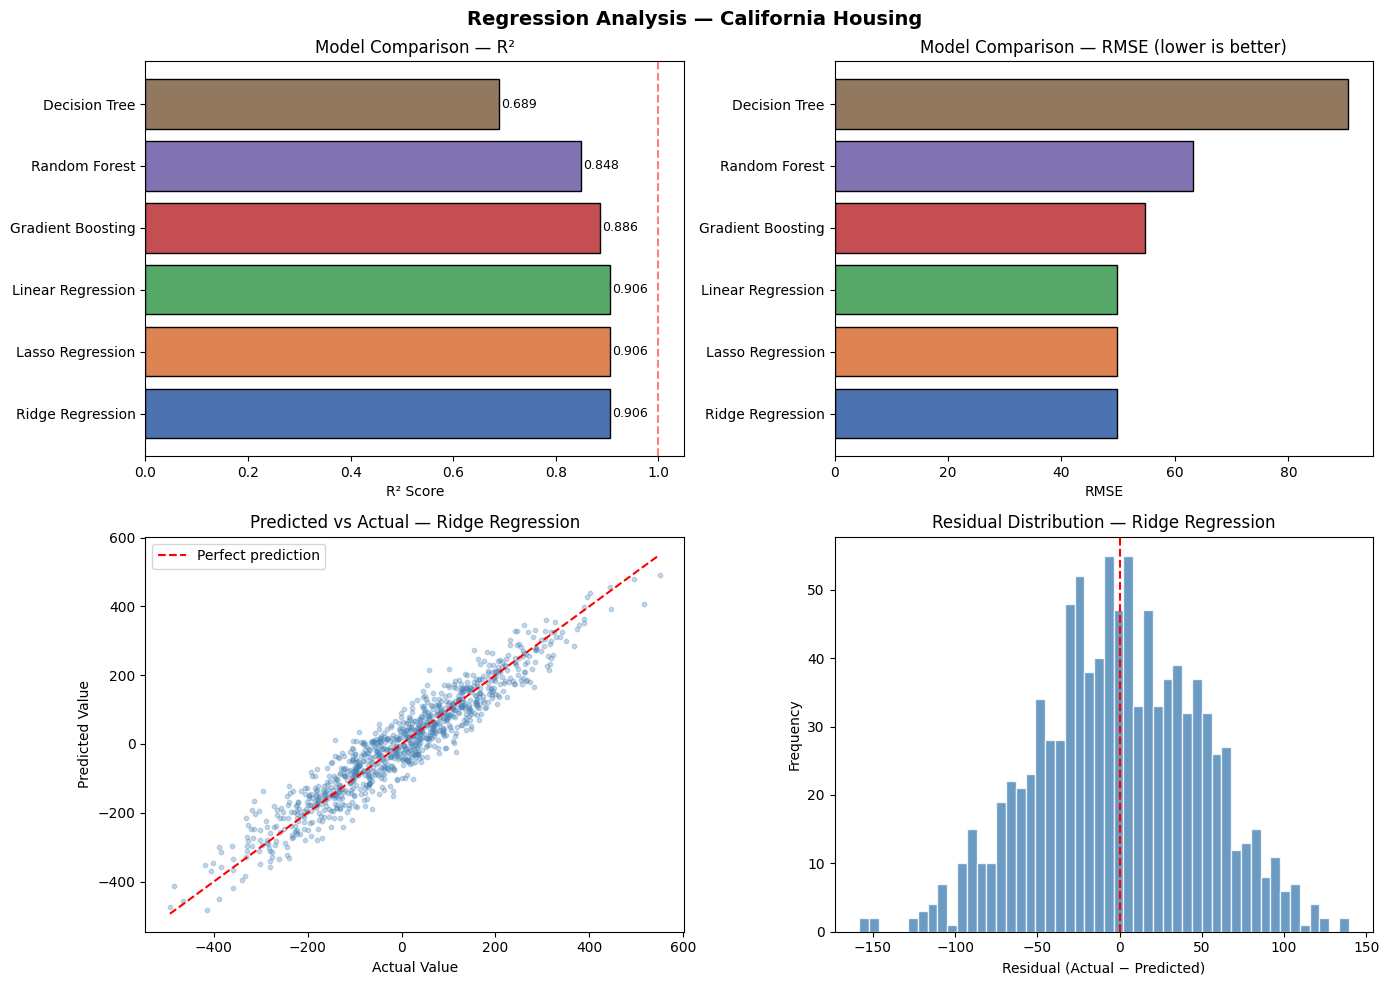

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Regression Analysis — California Housing", fontsize=14, fontweight="bold")

# R² comparison bar chart
ax = axes[0, 0]
ax.barh(results_df["Model"], results_df["R²"], color=sns_colors[:len(models)], edgecolor="black")
ax.set_xlabel("R² Score"); ax.set_title("Model Comparison — R²")
ax.axvline(1.0, color="red", linestyle="--", alpha=0.5)
ax.set_xlim(0, 1.05)
for i, v in enumerate(results_df["R²"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

# RMSE comparison
ax = axes[0, 1]
ax.barh(results_df["Model"], results_df["RMSE"], color=sns_colors[:len(models)], edgecolor="black")
ax.set_xlabel("RMSE"); ax.set_title("Model Comparison — RMSE (lower is better)")

# Predicted vs Actual — best model
y_pred_best = predictions[best_model_name]
ax = axes[1, 0]
ax.scatter(y_test, y_pred_best, alpha=0.3, s=10, color="steelblue")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Value"); ax.set_ylabel("Predicted Value")
ax.set_title(f"Predicted vs Actual — {best_model_name}")
ax.legend()

# Residuals — best model
residuals = y_test - y_pred_best
ax = axes[1, 1]
ax.hist(residuals, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Residual (Actual − Predicted)")
ax.set_ylabel("Frequency")
ax.set_title(f"Residual Distribution — {best_model_name}")

plt.tight_layout()
plt.show()
#plt.savefig("regression_results.png", dpi=120)
#plt.close()
#print("\n✓ Saved: regression_results.png")

# Feature importance (if tree-based)
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"Feature Importances — {best_model_name}")
    ax.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.show()
   # plt.savefig("regression_feature_importance.png", dpi=120)
    #plt.close()
    #print("✓ Saved: regression_feature_importance.png")

results_df.to_csv("regression_model_results.csv", index=False)
#print("✓ Saved: regression_model_results.csv")


LEVEL 2 — TASK 2 : Classification with Logistic Regression
Dataset  : Breast Cancer Wisconsin (sklearn)
Tools    : pandas, scikit-learn, matplotlib

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay
)

1. Load data

In [75]:
print("=== Classification — Breast Cancer (Malignant vs Benign) ===\n")
data = load_breast_cancer(as_frame=True)
df = data.frame
df["target_name"] = df["target"].map({0: "malignant", 1: "benign"})

print(f"Shape: {df.shape}")
print(f"Class distribution:\n{df['target_name'].value_counts()}")
print(f"\nFeatures: {list(data.feature_names[:5])} ...")

X = df[data.feature_names]
y = df["target"]        # 0 = malignant, 1 = benign

=== Classification — Breast Cancer (Malignant vs Benign) ===

Shape: (569, 32)
Class distribution:
target_name
benign       357
malignant    212
Name: count, dtype: int64

Features: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')] ...


2. Preprocessing

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")



Train: 455 | Test: 114


3. Train classifiers

In [77]:
classifiers = {
    "Logistic Regression"  : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"        : DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest"        : RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)"            : SVC(kernel="rbf", probability=True, random_state=42),
}

results  = []
roc_data = {}

print("\n── Classifier Comparison ───────────────────────────────────")
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>8}")
print("─" * 65)

for name, clf in classifiers.items():
    clf.fit(X_train_s, y_train)
    y_pred  = clf.predict(X_test_s)
    y_prob  = clf.predict_proba(X_test_s)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    roc_data[name] = (fpr, tpr, roc_auc)
    results.append({"Model": name, "Accuracy": acc, "Precision": prec,
                    "Recall": rec, "F1": f1, "AUC": roc_auc})
    print(f"  {name:<20} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>8.4f}")



── Classifier Comparison ───────────────────────────────────
Model                    Accuracy  Precision     Recall       F1
─────────────────────────────────────────────────────────────────
  Logistic Regression      0.9825     0.9861     0.9861   0.9861
  Decision Tree            0.9211     0.9565     0.9167   0.9362
  Random Forest            0.9561     0.9589     0.9722   0.9655
  SVM (RBF)                0.9825     0.9861     0.9861   0.9861


4. Detailed report for best model (Logistic Regression focus)

In [78]:
lr = classifiers["Logistic Regression"]
y_pred_lr = lr.predict(X_test_s)

print("\n── Full Report: Logistic Regression ────────────────────────")
print(classification_report(y_test, y_pred_lr,
                             target_names=["Malignant", "Benign"]))



── Full Report: Logistic Regression ────────────────────────
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



5. Visualizations

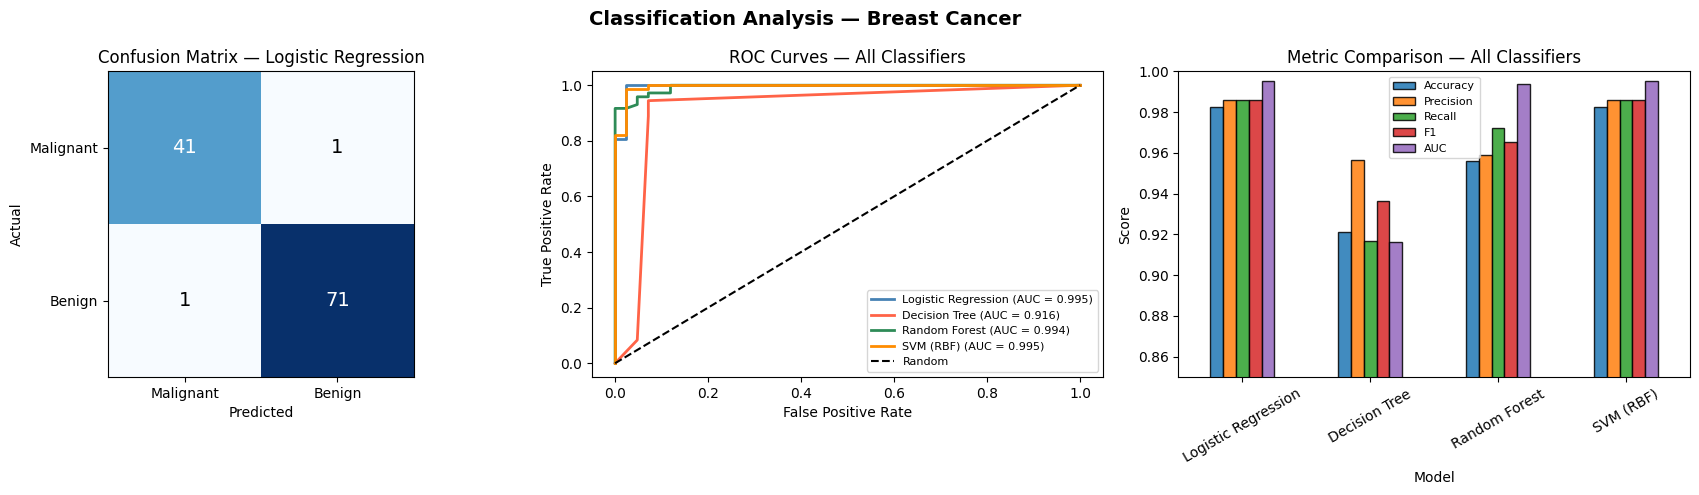

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Classification Analysis — Breast Cancer", fontsize=14, fontweight="bold")
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Malignant", "Benign"])
axes[0].set_yticklabels(["Malignant", "Benign"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix — Logistic Regression")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
# ROC curves
colors = ["steelblue", "tomato", "seagreen", "darkorange"]
for (name, (fpr, tpr, roc_auc)), color in zip(roc_data.items(), colors):
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves — All Classifiers"); axes[1].legend(fontsize=8)

# Metric comparison bar chart
res_df = pd.DataFrame(results).set_index("Model")
res_df[["Accuracy", "Precision", "Recall", "F1", "AUC"]].plot(
    kind="bar", ax=axes[2], edgecolor="black", alpha=0.85)
axes[2].set_title("Metric Comparison — All Classifiers")
axes[2].set_ylabel("Score"); axes[2].set_ylim(0.85, 1.0)
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
#plt.savefig("classification_results.png", dpi=120)
#plt.close()
#print("\n✓ Saved: classification_results.png")

5-Fold CV for Logistic Regression

In [80]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1 = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                         X_train_s, y_train, cv=cv, scoring="f1")
print(f"\n5-Fold CV F1 — Logistic Regression: {cv_f1.round(4)} | Mean: {cv_f1.mean():.4f}")

pd.DataFrame(results).to_csv("classification_results.csv", index=False)
print("✓ Saved: classification_results.csv")



5-Fold CV F1 — Logistic Regression: [0.9744 0.9912 0.9825 0.9913 0.9735] | Mean: 0.9825
✓ Saved: classification_results.csv


LEVEL 3 — TASK 1 : Time Series Analysis & Forecasting
Dataset  : Monthly airline passengers (classic benchmark)
Tools    : pandas, statsmodels, matplotlib

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error


1. Load dataset

In [82]:
print("=== Time Series Analysis — Monthly Airline Passengers ===\n")

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
try:
    df = pd.read_csv(url, parse_dates=["Month"], index_col="Month")
    df.columns = ["Passengers"]
except Exception:
    # Fallback: generate synthetic seasonal data
    np.random.seed(42)
    dates = pd.date_range("1949-01", periods=144, freq="MS")
    t     = np.arange(144)
    series = 100 + 2 * t + 50 * np.sin(2 * np.pi * t / 12) + np.random.normal(0, 10, 144)
    df = pd.DataFrame({"Passengers": series.astype(int)}, index=dates)
    print("  (Using synthetic data — no internet access)")

print(f"Shape: {df.shape}")
print(f"Date range: {df.index[0]} → {df.index[-1]}")
print(df.describe())

=== Time Series Analysis — Monthly Airline Passengers ===

Shape: (144, 1)
Date range: 1949-01-01 00:00:00 → 1960-12-01 00:00:00
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


2. Train / Test split

In [83]:
train = df.iloc[:-24]    # use last 24 months as test
test  = df.iloc[-24:]
print(f"\nTrain: {len(train)} months | Test: {len(test)} months")


Train: 120 months | Test: 24 months


3. Decomposition


── Seasonal Decomposition (multiplicative) ─────────────


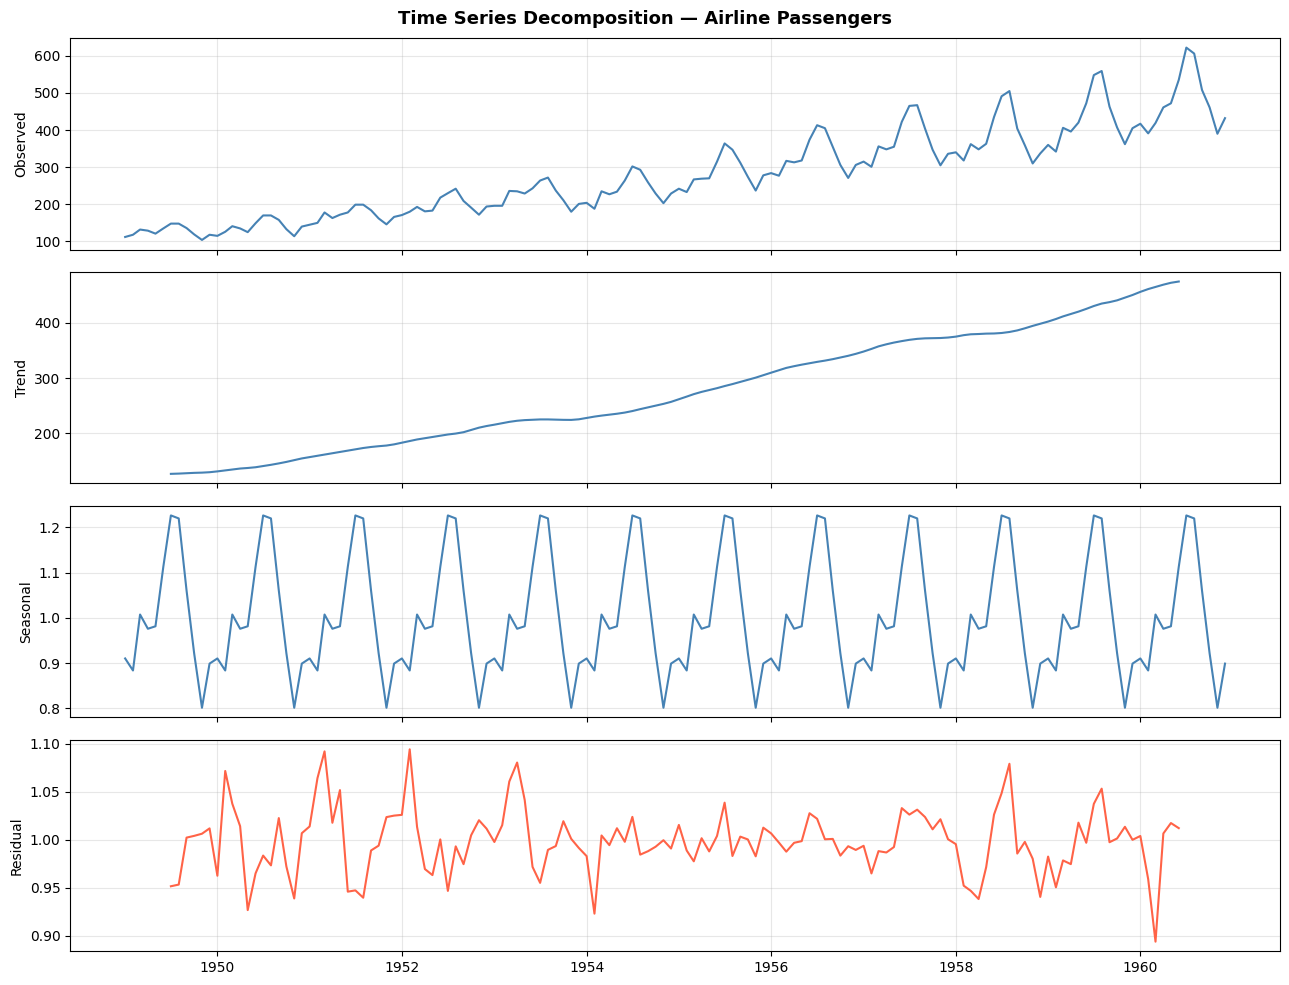

In [84]:
print("\n── Seasonal Decomposition (multiplicative) ─────────────")
decomp = seasonal_decompose(df["Passengers"], model="multiplicative", period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
fig.suptitle("Time Series Decomposition — Airline Passengers", fontsize=13, fontweight="bold")
for ax, (name, data) in zip(axes, [
    ("Observed",  decomp.observed),
    ("Trend",     decomp.trend),
    ("Seasonal",  decomp.seasonal),
    ("Residual",  decomp.resid),
]):
    ax.plot(data, color="steelblue" if name != "Residual" else "tomato")
    ax.set_ylabel(name)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
#plt.savefig("ts_decomposition.png", dpi=120)
#plt.close()
#print("✓ Saved: ts_decomposition.png")

4. Stationarity Test (ADF)

In [85]:
print("\n── Augmented Dickey-Fuller Test ─────────────────────────")
def adf_test(series, label="Series"):
    result = adfuller(series.dropna())
    print(f"\n  {label}:")
    print(f"    ADF Statistic : {result[0]:.4f}")
    print(f"    p-value       : {result[1]:.4f}")
    print(f"    Stationary    : {'YES ✓' if result[1] < 0.05 else 'NO ✗ — differencing needed'}")

adf_test(df["Passengers"], "Original series")
adf_test(np.log(df["Passengers"]).diff(12).dropna(), "Log + seasonal diff (d=1, D=1, s=12)")


── Augmented Dickey-Fuller Test ─────────────────────────

  Original series:
    ADF Statistic : 0.8154
    p-value       : 0.9919
    Stationary    : NO ✗ — differencing needed

  Log + seasonal diff (d=1, D=1, s=12):
    ADF Statistic : -2.7096
    p-value       : 0.0724
    Stationary    : NO ✗ — differencing needed


5. Moving Average & Exponential Smoothing

In [86]:
df["MA_12"]  = df["Passengers"].rolling(window=12).mean()
df["EWM_0.3"] = df["Passengers"].ewm(alpha=0.3, adjust=False).mean()


6. SARIMA Model

In [87]:
print("\n── SARIMA(1,1,1)(1,1,1,12) ─────────────────────────────")
sarima = SARIMAX(
    train["Passengers"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
result_sarima = sarima.fit(disp=False)
print(result_sarima.summary().tables[0])


── SARIMA(1,1,1)(1,1,1,12) ─────────────────────────────
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -348.860
Date:                            Wed, 17 Jun 2026   AIC                            707.720
Time:                                    14:24:42   BIC                            720.383
Sample:                                01-01-1949   HQIC                           712.833
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         


In [88]:
# Forecast
forecast_obj  = result_sarima.get_forecast(steps=24)
fc_mean       = forecast_obj.predicted_mean
fc_conf       = forecast_obj.conf_int()

rmse = np.sqrt(mean_squared_error(test["Passengers"], fc_mean))
mae  = mean_absolute_error(test["Passengers"], fc_mean)
print(f"\n  Test RMSE : {rmse:.2f}")
print(f"  Test MAE  : {mae:.2f}")



  Test RMSE : 75.63
  Test MAE  : 69.90


7. ARIMA Model (comparison)

In [89]:
print("\n── ARIMA(2,1,2) — baseline comparison ─────────────────────")
arima = ARIMA(train["Passengers"], order=(2, 1, 2))
res_arima     = arima.fit()
fc_arima      = res_arima.forecast(steps=24)
rmse_arima    = np.sqrt(mean_squared_error(test["Passengers"], fc_arima))
print(f"  Test RMSE (ARIMA) : {rmse_arima:.2f}")
print(f"  Test RMSE (SARIMA): {rmse:.2f}  {'★ Better' if rmse < rmse_arima else ''}")


── ARIMA(2,1,2) — baseline comparison ─────────────────────
  Test RMSE (ARIMA) : 90.69
  Test RMSE (SARIMA): 75.63  ★ Better


8. Visualizations

,Actual,SARIMA
Month,,
1959-01-01,360,341.385971
1959-02-01,342,319.020537
1959-03-01,406,363.043238
1959-04-01,396,348.877839
1959-05-01,420,364.168036
1959-06-01,472,435.854028
1959-07-01,548,491.896015
1959-08-01,559,505.984219
1959-09-01,463,404.549607


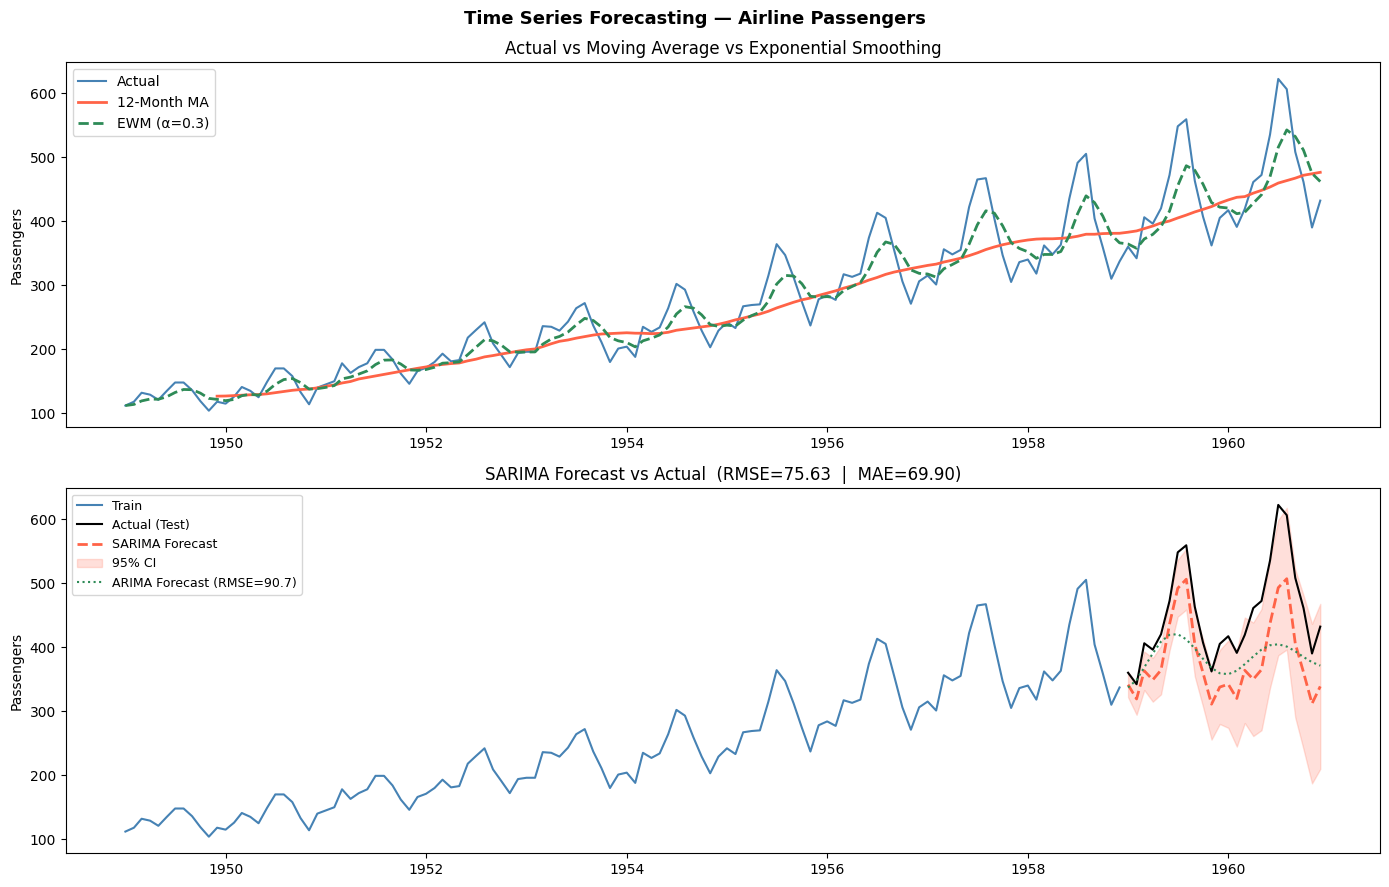

In [90]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("Time Series Forecasting — Airline Passengers", fontsize=13, fontweight="bold")

# MA & EWM
ax = axes[0]
ax.plot(df["Passengers"], label="Actual", color="steelblue", linewidth=1.5)
ax.plot(df["MA_12"],      label="12-Month MA", color="tomato", linewidth=2)
ax.plot(df["EWM_0.3"],    label="EWM (α=0.3)", color="seagreen", linewidth=2, linestyle="--")
ax.set_title("Actual vs Moving Average vs Exponential Smoothing")
ax.legend(); ax.set_ylabel("Passengers")

# SARIMA forecast
ax = axes[1]
ax.plot(train["Passengers"], label="Train", color="steelblue", linewidth=1.5)
ax.plot(test["Passengers"],  label="Actual (Test)", color="black", linewidth=1.5)
ax.plot(fc_mean,             label="SARIMA Forecast", color="tomato", linewidth=2, linestyle="--")
ax.fill_between(fc_conf.index, fc_conf.iloc[:, 0], fc_conf.iloc[:, 1],
                alpha=0.2, color="tomato", label="95% CI")
ax.plot(fc_arima,            label=f"ARIMA Forecast (RMSE={rmse_arima:.1f})",
        color="seagreen", linewidth=1.5, linestyle=":")
ax.set_title(f"SARIMA Forecast vs Actual  (RMSE={rmse:.2f}  |  MAE={mae:.2f})")
ax.legend(fontsize=9); ax.set_ylabel("Passengers")

plt.tight_layout()
plt
#plt.savefig("ts_forecast.png", dpi=120)
#plt.close()
#print("\n✓ Saved: ts_forecast.png")

results = pd.DataFrame({"Actual": test["Passengers"].values, "SARIMA": fc_mean.values})
results.index = test.index
results.to_csv("ts_forecast_results.csv")
results
#print("✓ Saved: ts_forecast_results.csv")


LEVEL 3 — TASK 3 : Neural Networks with TensorFlow / Keras
Dataset  : MNIST Handwritten Digits (via Keras)
Tools    : Python, TensorFlow, Keras, pandas, matplotlib

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
tf.random.set_seed(42)
np.random.seed(42)



TensorFlow version: 2.20.0


1. Load and preprocess MNIST

In [92]:
print("\n=== Neural Network — MNIST Digit Classification ===\n")

(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.mnist.load_data()

print(f"Train shape: {X_train_raw.shape}  |  Test shape: {X_test_raw.shape}")
print(f"Pixel range: {X_train_raw.min()} – {X_train_raw.max()}")

# Normalize to [0, 1]
X_train = X_train_raw.astype("float32") / 255.0
X_test  = X_test_raw.astype("float32")  / 255.0

# Reshape for Dense layers: (N, 28, 28) → (N, 784)
X_train_flat = X_train.reshape(-1, 784)
X_test_flat  = X_test.reshape(-1, 784)

# One-hot encode labels
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh  = keras.utils.to_categorical(y_test, 10)

# Validation split
val_size = 10000
X_val,   X_tr   = X_train_flat[:val_size],  X_train_flat[val_size:]
y_val_oh, y_tr_oh = y_train_oh[:val_size],  y_train_oh[val_size:]
y_val,   y_tr   = y_train[:val_size],        y_train[val_size:]

print(f"Train: {X_tr.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test_flat.shape[0]}")



=== Neural Network — MNIST Digit Classification ===

Train shape: (60000, 28, 28)  |  Test shape: (10000, 28, 28)
Pixel range: 0 – 255
Train: 50000  |  Val: 10000  |  Test: 10000


2. Visualize sample digits

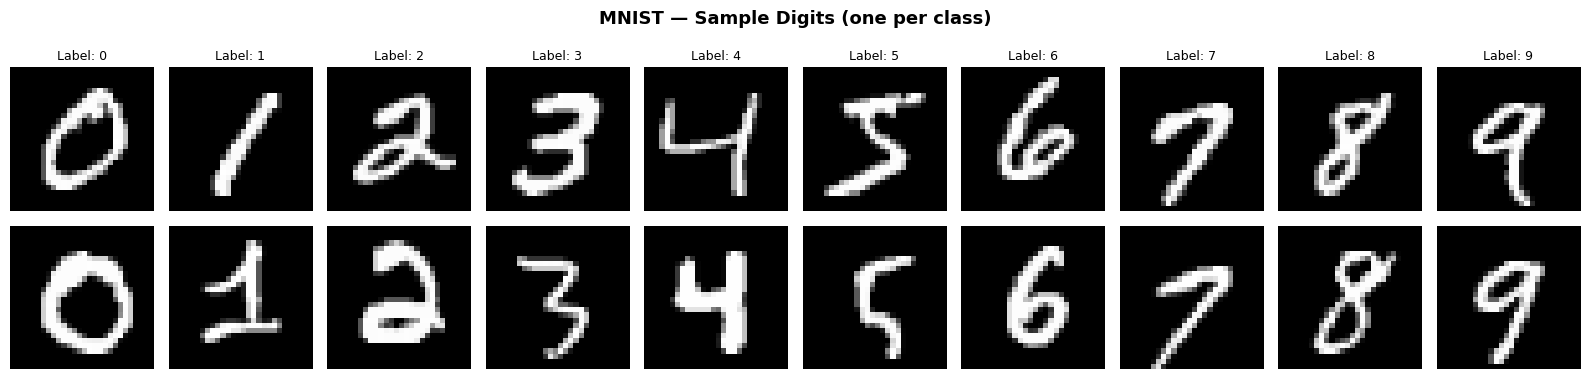

In [93]:
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle("MNIST — Sample Digits (one per class)", fontsize=13, fontweight="bold")
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes[0, digit].imshow(X_train_raw[idx], cmap="gray")
    axes[0, digit].set_title(f"Label: {digit}", fontsize=9)
    axes[0, digit].axis("off")
    # Second row: another example
    idx2 = np.where(y_train == digit)[0][5]
    axes[1, digit].imshow(X_train_raw[idx2], cmap="gray")
    axes[1, digit].axis("off")
plt.tight_layout()
plt.show()
#plt.savefig("nn_sample_digits.png", dpi=120)
#plt.close()
#print("✓ Saved: nn_sample_digits.png")

 3. Build Model A — Simple baseline

In [94]:
print("\n── Model A: Simple Baseline (1 hidden layer) ───────────")
model_A = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10,  activation="softmax"),
], name="SimpleNet")

model_A.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model_A.summary()

hist_A = model_A.fit(
    X_tr, y_tr_oh,
    validation_data=(X_val, y_val_oh),
    epochs=15, batch_size=128, verbose=1,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

loss_A, acc_A = model_A.evaluate(X_test_flat, y_test_oh, verbose=0)
print(f"\n  Test Accuracy (Simple): {acc_A*100:.2f}%")


── Model A: Simple Baseline (1 hidden layer) ───────────


Model: "SimpleNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8920 - loss: 0.3926 - val_accuracy: 0.9391 - val_loss: 0.2182
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9477 - loss: 0.1831 - val_accuracy: 0.9525 - val_loss: 0.1621
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9616 - loss: 0.1342 - val_accuracy: 0.9602 - val_loss: 0.1339
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9697 - loss: 0.1046 - val_accuracy: 0.9637 - val_loss: 0.1170
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9761 - loss: 0.0842 - val_accuracy: 0.9687 - val_loss: 0.1052
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9808 - loss: 0.0692 - val_accuracy: 0.9710 - val_loss: 0.0976
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9843 - loss: 0.0575 - val_accuracy: 0.9724 - val_loss: 0.0926
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9873 - loss: 0.0481 - val_accuracy: 0.

4. Build Model B — Tuned deep network

In [95]:
print("\n── Model B: Deep Network with Dropout & BatchNorm ─────")
model_B = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10,  activation="softmax"),
], name="DeepNet")

model_B.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model_B.summary()

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor="val_loss", verbose=1)
]

hist_B = model_B.fit(
    X_tr, y_tr_oh,
    validation_data=(X_val, y_val_oh),
    epochs=30, batch_size=256, verbose=1,
    callbacks=callbacks
)

loss_B, acc_B = model_B.evaluate(X_test_flat, y_test_oh, verbose=0)
print(f"\n  Test Accuracy (Deep): {acc_B*100:.2f}%")


── Model B: Deep Network with Dropout & BatchNorm ─────


Model: "DeepNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8897 - loss: 0.3595 - val_accuracy: 0.9338 - val_loss: 0.2726 - learning_rate: 0.0010
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9512 - loss: 0.1585 - val_accuracy: 0.9694 - val_loss: 0.1018 - learning_rate: 0.0010
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9637 - loss: 0.1171 - val_accuracy: 0.9726 - val_loss: 0.0911 - learning_rate: 0.0010
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9699 - loss: 0.0932 - val_accuracy: 0.9751 - val_loss: 0.0818 - learning_rate: 0.0010
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9752 - loss: 0.0782 - val_accuracy: 0.9770 - val_loss: 0.0801 - learning_rate: 0.0010
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9788 - loss: 0.0668 - val_accuracy: 0.9781 - val_loss: 0.0791 - learning_rate: 0.0010
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9803 - loss: 0.

5. Model comparison

In [96]:
print(f"\n── Summary ─────────────────────────────────────────────")
print(f"  Simple baseline  : {acc_A*100:.2f}%")
print(f"  Deep + Dropout   : {acc_B*100:.2f}%")


── Summary ─────────────────────────────────────────────
  Simple baseline  : 97.51%
  Deep + Dropout   : 98.55%


6. Classification report

In [97]:
y_pred_B = np.argmax(model_B.predict(X_test_flat, verbose=0), axis=1)
print("\n── Classification Report — Deep Model ──────────────────")
print(classification_report(y_test, y_pred_B,
      target_names=[str(i) for i in range(10)]))


── Classification Report — Deep Model ──────────────────
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.99      0.99       892
           6       0.99      0.98      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



7. Visualizations

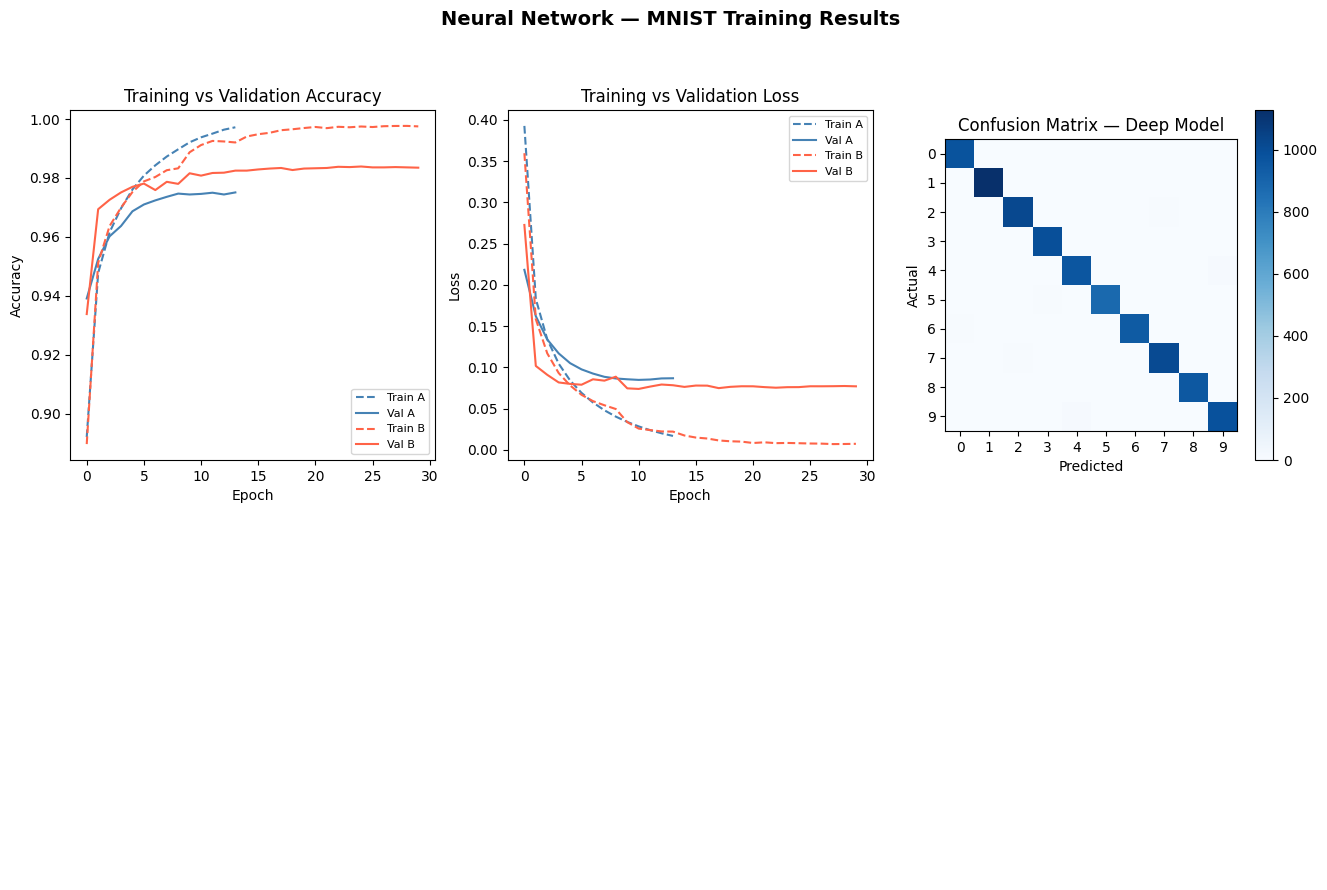

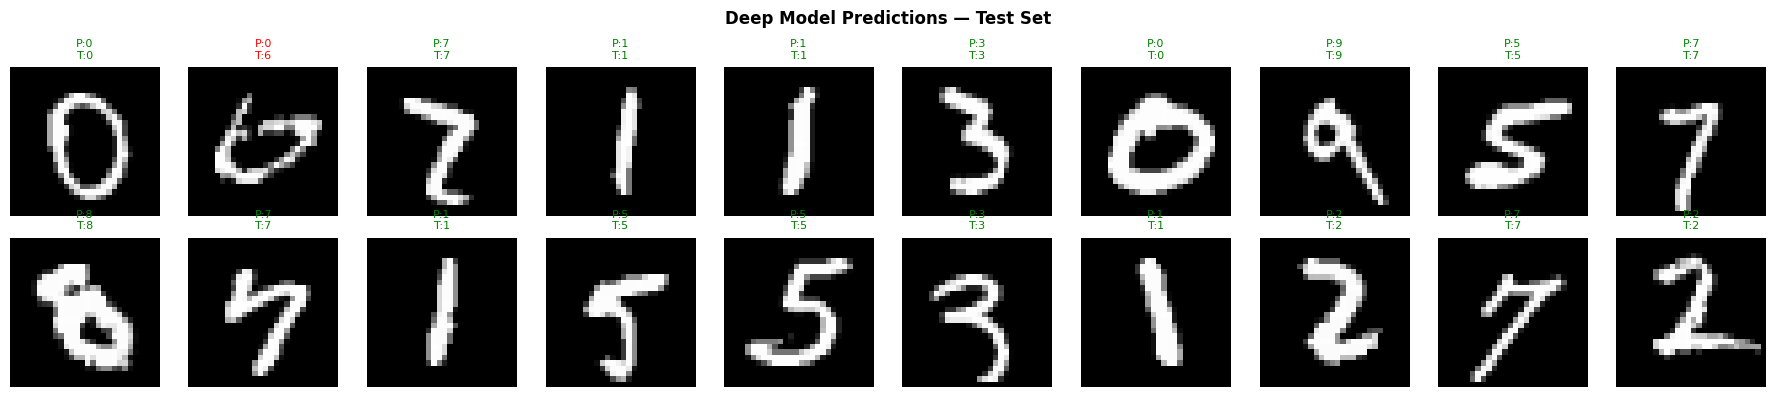

In [98]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Neural Network — MNIST Training Results", fontsize=14, fontweight="bold")

# Training curves — accuracy
ax = axes[0, 0]
ax.plot(hist_A.history["accuracy"],     label="Train A", linestyle="--", color="steelblue")
ax.plot(hist_A.history["val_accuracy"], label="Val A",   linestyle="-",  color="steelblue")
ax.plot(hist_B.history["accuracy"],     label="Train B", linestyle="--", color="tomato")
ax.plot(hist_B.history["val_accuracy"], label="Val B",   linestyle="-",  color="tomato")
ax.set_title("Training vs Validation Accuracy")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.legend(fontsize=8)

# Training curves — loss
ax = axes[0, 1]
ax.plot(hist_A.history["loss"],     label="Train A", linestyle="--", color="steelblue")
ax.plot(hist_A.history["val_loss"], label="Val A",   linestyle="-",  color="steelblue")
ax.plot(hist_B.history["loss"],     label="Train B", linestyle="--", color="tomato")
ax.plot(hist_B.history["val_loss"], label="Val B",   linestyle="-",  color="tomato")
ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(fontsize=8)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_B)
im = axes[0, 2].imshow(cm, cmap="Blues")
axes[0, 2].set_title("Confusion Matrix — Deep Model")
axes[0, 2].set_xlabel("Predicted"); axes[0, 2].set_ylabel("Actual")
plt.colorbar(im, ax=axes[0, 2])
axes[0, 2].set_xticks(range(10)); axes[0, 2].set_yticks(range(10))

# Sample predictions
axes[1, 0].axis("off"); axes[1, 1].axis("off"); axes[1, 2].axis("off")
fig2, axs = plt.subplots(2, 10, figsize=(18, 4))
fig2.suptitle("Deep Model Predictions — Test Set", fontsize=12, fontweight="bold")
np.random.seed(123)
sample_idx = np.random.choice(len(X_test_flat), 20, replace=False)
for i, idx in enumerate(sample_idx):
    ax = axs[i // 10, i % 10]
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    pred  = y_pred_B[idx]
    truth = y_test[idx]
    color = "green" if pred == truth else "red"
    ax.set_title(f"P:{pred}\nT:{truth}", color=color, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()
#plt.savefig("nn_predictions.png", dpi=120)
#plt.close()
#plt.savefig("nn_training_curves.png", dpi=120)
#plt.close()

8. Save results

In [99]:
model_B.save("mnist_deep_model.keras")
print("✓ Saved: mnist_deep_model.keras")

summary_df = pd.DataFrame({
    "Model"    : ["Simple Baseline", "Deep + Dropout"],
    "Accuracy" : [f"{acc_A*100:.2f}%", f"{acc_B*100:.2f}%"],
    "Params"   : [model_A.count_params(), model_B.count_params()],
})
print("\n── Final Model Summary ─────────────────────────────────")
print(summary_df.to_string(index=False))

✓ Saved: mnist_deep_model.keras

── Final Model Summary ─────────────────────────────────
          Model Accuracy  Params
Simple Baseline   97.51%  101770
 Deep + Dropout   98.55%  570506
